# Extended depth-of-focus

In [1]:
import torch
import sys
import os
sys.path.append('../')
from DataType.ElectricField import ElectricField
from LightSource.Gaussian_beam import Guassian_beam
from LightSource.PlaneWave import PlaneWave
from Props.ASM_Prop import ASM_prop
from Props.RSC_Prop import RSC_prop
from Components.Thin_Lens import Thin_LensElement
from Components.Aperture import ApertureElement
from Components.QuantizedDOE import RotationallySymmetricScoreGumbelSoftQuantizedDOELayer as SoftGumbelQuantizedDOELayer
from Components.QuantizedDOE import RotationallySymmetricSTEQuantizedDOELayer as STEQuantizedDOELayer
from Components.QuantizedDOE import RotationallySymmetricNaiveGumbelQuantizedDOELayer as NaiveGumbelQuantizedDOELayer
from Components.QuantizedDOE import RotationallySymmetricPSQuantizedQuantizedDOELayer as PSQuantizedDOELayer
from Components.QuantizedDOE import RotationallySymmetricFullPrecisionDOELayer as FullPrecisionDOELayer
from Components.QuantizedDOE import FixDOEElement
from utils.Helper_Functions import normalize, DOE_xyz_cordinates_Generator
from utils.units import *
import numpy as np
import scipy.io
import time
import torch.nn as nn
import random

In [2]:
# Hologram parameters (high-temp resin)
epsilon = 2.66
tand = 0.0
    
input_field_shape = [100, 100]
input_dxy = 1 * mm
doe_shape = [100, 100]
doe_dxy = 1 * mm
    
    
c0 = 2.998e8
f2 = 300e9  # 0.3 THz

wavelengths = c0 / f2
#print("The number of wavelengths: " +  str(wavelengths.shape[0]))

# all parameters of DOE optimization
doe_params = {
    'doe_size': doe_shape,
    'doe_dxy' : doe_dxy,
    'doe_level': 4,
    'look_up_table': None,
    'num_unit': None,
    'height_constraint_max': 1 * mm,
    'tolerance': 0 * um,  
    'material': [epsilon, tand]
}

optim_params = {
    'c_s': 50,
    'tau_max': 5.5,
    'tau_min': 4.0
}

optim_params = {
    'c_s': 100,   # a number to boost the score (higher more robust to gumbel noise)
    'tau_max': 2.5, # maximum value of tau
    'tau_min': 1.5  # minimum value of tau
}

In [3]:
import numpy as np
from PIL import Image
from utils.Helper_Functions import normalize
import matplotlib.pyplot as plt
import torch.nn.functional as F
def define_FoM(resolution, sampling_size, wavelength, focal_length, position):
    """
    Calculates the Full-width-at-half-maximum (FWHM) by the far-field diffraction limit
    and applies it to model the point spread function (PSF) as a Gaussian function, with consistent intensity across positions.
    
    Parameters:
        resolution (tuple): The resolution of the field in pixels (height, width).
        sampling_size (float): The physical size of each pixel, in meters.
        wavelength (float): The wavelength of the light, in meters.
        focal_length (float): The focal length of the optical system, in meters.
        position (tuple): The target position in the field, in meters (x, y).
        
    Returns:
        torch.Tensor: The calculated and normalized PSF as a 2D Gaussian function over the specified field.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    height, width = resolution
    Length_x = sampling_size * width
    Length_y = sampling_size * height
    
    effective_L = torch.sqrt(torch.tensor((Length_x ** 2 + Length_y ** 2), device=device))
    NA = torch.sin(torch.atan(effective_L / (2 * focal_length)))
    FWHM = wavelength / (2 * NA)
    
    x_grid, y_grid = torch.meshgrid(torch.linspace(-Length_x / 2, Length_x / 2, steps=width, device=device),
                                    torch.linspace(-Length_y / 2, Length_y / 2, steps=height, device=device))
    
    x_position, y_position = torch.tensor(position, device=device)
    
    # Calculate the Gaussian PSF
    PSF = torch.exp(-((x_grid - x_position) ** 2 + (y_grid - y_position) ** 2) / ((FWHM*2) ** 2))
    
    # Normalize the PSF such that its maximum value is 1
    
    return normalize(PSF.unsqueeze(0).unsqueeze(0))

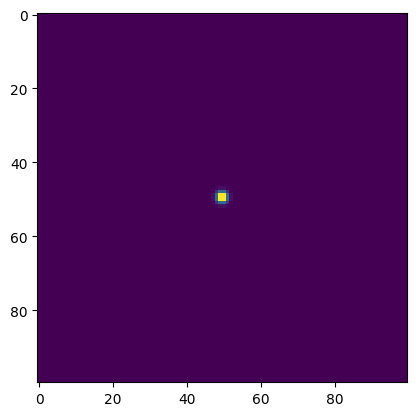

In [4]:
PSF_1 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=70*mm, position=[0*mm, 0*mm])

target = PSF_1
plt.imshow(target[0, 0, :, :].cpu())

In [50]:
class Setup(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 optim_params,
                 wavelengths, 
                 q_method,
                 device='cuda:0'):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        self.optim_params = optim_params
        self.device = device
        self.wavelengths = wavelengths

        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        if q_method == None:
            self.doe = FullPrecisionDOELayer(self.doe_params)
            
        elif q_method == 'sgs':
            self.doe = SoftGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'gs':
            self.doe = NaiveGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'psq':
            optim_params = {'c_s': 300,'tau_max': 800,'tau_min': 1}
            self.doe = PSQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'ste':
            self.doe = STEQuantizedDOELayer(self.doe_params, self.optim_params)
        
        
        self.asm_prop1 = ASM_prop(z_distance=52 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop2 = ASM_prop(z_distance=56 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
        
        self.asm_prop3 = ASM_prop(z_distance=60 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop4 = ASM_prop(z_distance=64 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop5 = ASM_prop(z_distance=68 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop6 = ASM_prop(z_distance=72 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
        
        self.asm_prop7 = ASM_prop(z_distance=76 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop8 = ASM_prop(z_distance=80 * mm, 
                             bandlimit_type='exact', 
                             padding_scale=4, 
                             bandlimit_kernel=True)

        self.asm_prop9 = ASM_prop(z_distance=84 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

        self.asm_prop10 = ASM_prop(z_distance=88 * mm, 
                             bandlimit_type='exact', 
                             padding_scale=4, 
                             bandlimit_kernel=True)

    
    def forward(self, iter_frac):
        input_field = self.source()
        
        field = self.aperture(self.doe(input_field, iter_frac))

        delta_z = 2 * mm
        
        final_field1 = self.asm_prop1(field).data
        final_field2 = self.asm_prop2(field).data
        final_field3 = self.asm_prop3(field).data
        final_field4 = self.asm_prop4(field).data
        final_field5 = self.asm_prop5(field).data
        final_field6 = self.asm_prop6(field).data
        final_field7 = self.asm_prop7(field).data
        final_field8 = self.asm_prop8(field).data
        final_field9 = self.asm_prop9(field).data
        final_field10 = self.asm_prop10(field).data

        self.asm_prop1.z =52*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop2.z =56*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop3.z =60*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop4.z =64*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop5.z =68*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop6.z =72*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop7.z =76*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop8.z =80*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop9.z =84*mm + random.uniform(-delta_z*mm, delta_z*mm)
        self.asm_prop10.z =88*mm + random.uniform(-delta_z*mm, delta_z*mm)

        total_field = torch.cat([final_field1, final_field2, final_field3, final_field4, final_field5,
                                 final_field6, final_field7, final_field8, final_field9, final_field10], dim=1)

        intensities = total_field.abs()**2

        normalized_intensities = intensities / torch.max(intensities)
        
        return normalized_intensities

class Submm_Setup_test(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 wavelengths, 
                 doe_data):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        
        self.wavelengths = wavelengths

        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        self.doe = FixDOEElement(height_map=doe_data, 
                                 tolerance=0*mm, 
                                 material=self.doe_params['material'])
        
        self.prop_range = np.linspace(1*mm, 100*mm, num=200)
        self.asm_prop3 = ASM_prop(z_distance=1 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
    
    def forward(self):
        fields_zx = []
        input_field = self.source()
        field = self.aperture(self.doe(input_field))
        final_field = self.asm_prop3(field)

        #field_data = final_field.data[0, 0, 49, :]
        #print(field_data.shape)
        #fields_zx.append(field_data)  # Use parentheses here
        
        for z in self.prop_range:
            self.asm_prop3.z = z
            final_field = self.asm_prop3(field)
            field_data = final_field.data[0, 0, 49, :]
            fields_zx.append(field_data)  # Use parentheses here

        stacked_fields_zx = torch.stack(fields_zx)
        
        return stacked_fields_zx

In [51]:
setup = Setup(input_dxy=input_dxy, 
            input_field_shape=input_field_shape, 
            doe_params=doe_params, 
            optim_params=optim_params,
            wavelengths=wavelengths,
            q_method='psq')

In [52]:
max_itrs = 6000

losses = []
itr_list = []
itr_to_save_plots = []
setup.cuda()
target = target.cuda()
optimizer = torch.optim.AdamW(setup.parameters(), lr=5e-2)

photometric_loss_fn = nn.MSELoss()

best_loss = 10

for itr in range(max_itrs):
    norm_fields = setup.forward(iter_frac=itr/max_itrs)
    #print(norm_fields.shape)
    #break
    loss = photometric_loss_fn(norm_fields, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    #grad = setup.hologram.weight_height_map.grad
    #print(grad)

    losses.append(loss.item())
    itr_list.append(itr)
    
    if itr % 200 == 0 or itr == (max_itrs-1):
        print("The iteration : {}, Loss: {}".format(itr, loss))
        #out_field_1.visualize(flag_axis = True, figsize=(6,6), wavelength=wavelengths, intensity=True)
        #out_field_2.visualize(flag_axis = True, figsize=(6,6), wavelength=wavelengths, intensity=True)
    
    if loss < best_loss and itr > max_itrs * 0.8:
        best_setup = setup
        best_loss = loss

The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The critical distance is [0.4333979] m, the TF will be fine during the sampling !
The iteration : 0, Loss: 0.06292052567005157
The iteration : 200, Loss: 0.0005458428058773279
The iteration : 400, Loss: 0.00045306183164939284
The iteration : 600, Loss: 0.0004053

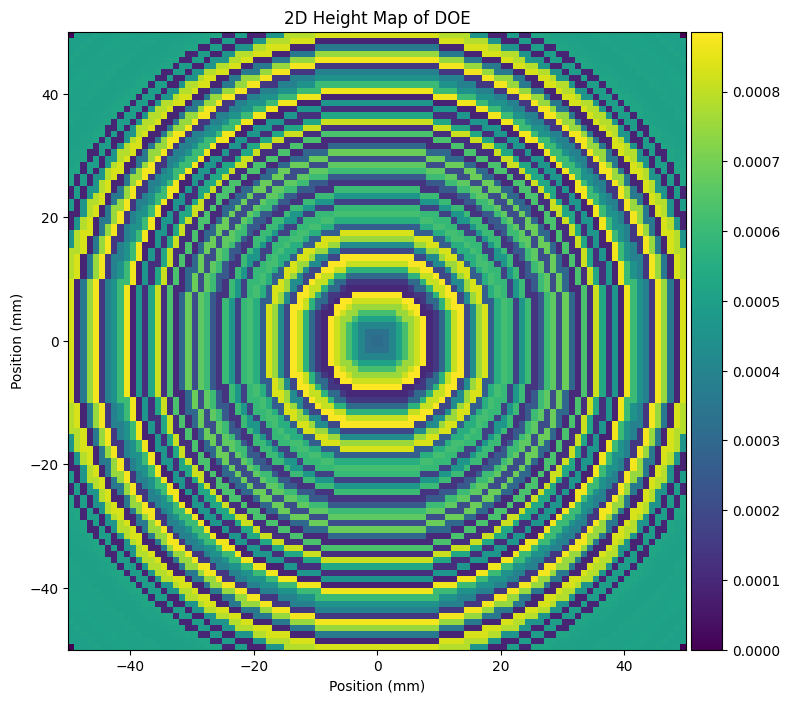

In [53]:
best_setup.doe.visualize(figsize=(8,8))

In [54]:
doe_data = best_setup.doe.height_map

setup_test = Submm_Setup_test(input_dxy=input_dxy, 
                              input_field_shape=input_field_shape, 
                              doe_params=doe_params, 
                              wavelengths=wavelengths, 
                              doe_data=doe_data)

data = setup_test.forward()
data = data[:, 10:-10].cpu().abs()**2

The critical distance is [0.4333979] m, the TF will be fine during the sampling !


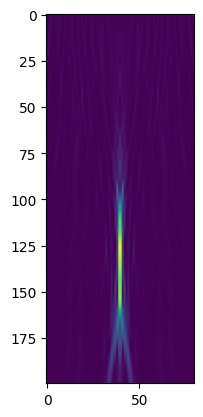

In [55]:
plt.imshow(data.detach().numpy())

tensor(0.1824, device='cuda:0', grad_fn=<DivBackward0>)


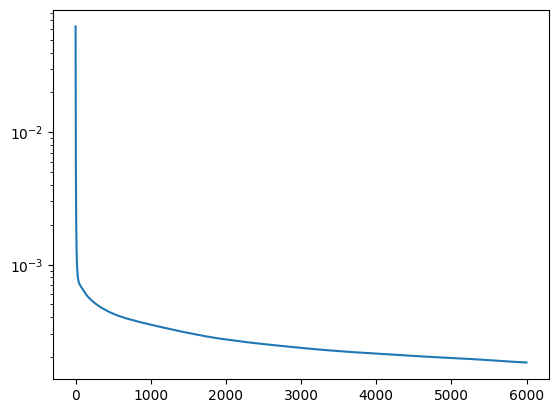

In [59]:
print(best_loss / mm)
np.save('loss_curve_edof_psq.npy', losses)
plt.plot(losses)
plt.yscale('log')

In [57]:
best_setup.doe.save(crop_size=[80, 80])

## Loss landscape

In [ ]:
class Args:
    def __init__(self):
        self.save_path = 'loss_landscape_results'  # Base path for saving loss landscape images
        self.ex_name = 'splitter_full'  # Type of Experiments
        self.xmin = -6    # Minimum value of x-coordinate
        self.xmax = 6     # Maximum value of x-coordinate
        self.xnum = 801    # Number of x-coordinate
        self.ymin = -6    # Minimum value of y-coordinate
        self.ymax = 6     # Maximum value of y-coordinate
        self.ynum = 801    # Number of y-coordinate
        self.save_imges = True
        self.surf_name = 'loss'    # The type of surface to plot
        self.vmin = 0.01        # Miminum value to map
        self.vmax = 1        # Maximum value to map
        self.vlevel = 0.1      # plot contours every vlevel

# Instantiate and use the Args class
args = Args()

save_path = os.path.join(args.save_path, args.ex_name) 
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [ ]:
from VisTools.directions import create_random_directions
from VisTools.calc_loss import calulate_single_element_loss_landscape
from VisTools.visualize import visualize_notebook

In [ ]:
rand_directions = create_random_directions(best_setup)
surface_path = calulate_single_element_loss_landscape(args, model=setup, target=target, loss_f=photometric_loss_fn, directions=rand_directions, save_path=save_path)
visualize_notebook(args, save_path, surface_path)

In [ ]:
class Submm_Setup_test(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 wavelengths, 
                 doe_data):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        
        self.wavelengths = wavelengths

        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        self.doe = FixDOEElement(height_map=doe_data, 
                                 tolerance=0*mm, 
                                 material=self.doe_params['material'])
        
        self.prop_range = np.linspace(20*mm, 90*mm, num=200)
        self.asm_prop3 = ASM_prop(z_distance=20 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
    
    def forward(self):
        fields_zx = []
        input_field = self.source()
        field = self.doe(input_field)
        final_field = self.asm_prop3(field)

        #field_data = final_field.data[0, 0, 49, :]
        #print(field_data.shape)
        #fields_zx.append(field_data)  # Use parentheses here
        
        for z in self.prop_range:
            self.asm_prop3.z = z
            final_field = self.asm_prop3(field)
            field_data = final_field.data[0, 0, 49, :]
            fields_zx.append(field_data)  # Use parentheses here

        stacked_fields_zx = torch.stack(fields_zx)
        
        return stacked_fields_zx

In [ ]:
#doe_data = best_setup.doe.height_map

doe_data = np.load('./FDTDval/data/edof_4levels.npy', allow_pickle=True)
doe_data = doe_data.item().get('thickness')
pad_width = ((10, 10), (10, 10))  # (top/bottom, left/right)
doe_data = np.pad(doe_data, pad_width, mode='constant', constant_values=0)  # Pad with zeros


setup_test = Submm_Setup_test(input_dxy=input_dxy, 
                              input_field_shape=input_field_shape, 
                              doe_params=doe_params, 
                              wavelengths=wavelengths, 
                              doe_data=doe_data)

data = setup_test.forward()

data = data.cpu().abs()**2


plt.imshow(data.detach().numpy())

In [ ]:
plt.plot(data[:, 49].detach().numpy())

In [ ]:
setup_test.doe.visualize(figsize=(8,8))

# Beam Splitter

In [62]:
import torch
import sys
sys.path.append('../')
from DataType.ElectricField import ElectricField
from LightSource.Gaussian_beam import Guassian_beam
from LightSource.PlaneWave import PlaneWave
from Props.ASM_Prop import ASM_prop
from Props.RSC_Prop import RSC_prop
from Components.Thin_Lens import Thin_LensElement
from Components.Aperture import ApertureElement
from Components.QuantizedDOE import SoftGumbelQuantizedDOELayerv3 as SoftGumbelQuantizedDOELayer
from Components.QuantizedDOE import NaiveGumbelQuantizedDOELayer
from Components.QuantizedDOE import PSQuantizedDOELayer
from Components.QuantizedDOE import STEQuantizedDOELayer
from Components.QuantizedDOE import FullPrecisionDOELayer
from utils.Helper_Functions import normalize, DOE_xyz_cordinates_Generator
from utils.units import *
import numpy as np
import scipy.io
import time
import torch.nn as nn

from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
# Hologram parameters (high-temp resin)
epsilon = 2.66
tand = 0.0
    
input_field_shape = [100, 100]
input_dxy = 1 * mm
doe_shape = [100, 100]
doe_dxy = 1 * mm
    
    
c0 = 3e8
f2 = 300e9  # 0.3 THz

wavelengths = c0 / f2
#print("The number of wavelengths: " +  str(wavelengths.shape[0]))

# all parameters of DOE optimization
doe_params = {
    'doe_size': doe_shape,
    'doe_dxy' : doe_dxy,
    'doe_level': 4,
    'look_up_table': None,
    'num_unit': 2,
    'height_constraint_max': 1 * mm,
    'tolerance': 10 * um,  
    'material': [epsilon, tand]
}

optim_params = {
    'c_s': 100,   # a number to boost the score (higher more robust to gumbel noise)
    'tau_max': 2.5, # maximum value of tau
    'tau_min': 1.5  # minimum value of tau
}

In [ ]:
def define_FoM(resolution, sampling_size, wavelength, focal_length, position):
    """
    Calculates the Full-width-at-half-maximum (FWHM) by the far-field diffraction limit
    and applies it to model the point spread function (PSF) as a Gaussian function, with consistent intensity across positions.
    
    Parameters:
        resolution (tuple): The resolution of the field in pixels (height, width).
        sampling_size (float): The physical size of each pixel, in meters.
        wavelength (float): The wavelength of the light, in meters.
        focal_length (float): The focal length of the optical system, in meters.
        position (tuple): The target position in the field, in meters (x, y).
        
    Returns:
        torch.Tensor: The calculated and normalized PSF as a 2D Gaussian function over the specified field.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    height, width = resolution
    Length_x = sampling_size * width
    Length_y = sampling_size * height
    
    effective_L = torch.sqrt(torch.tensor((Length_x ** 2 + Length_y ** 2), device=device))
    NA = torch.sin(torch.atan(effective_L / (2 * focal_length)))
    FWHM = wavelength / (2 * NA)
    
    x_grid, y_grid = torch.meshgrid(torch.linspace(-Length_x / 2, Length_x / 2, steps=width, device=device),
                                    torch.linspace(-Length_y / 2, Length_y / 2, steps=height, device=device))
    
    x_position, y_position = torch.tensor(position, device=device)
    
    # Calculate the Gaussian PSF
    PSF = torch.exp(-((x_grid - x_position) ** 2 + (y_grid - y_position) ** 2) / ((FWHM*2) ** 2))
    
    # Normalize the PSF such that its maximum value is 1
    
    return normalize(PSF.unsqueeze(0).unsqueeze(0))

In [ ]:
PSF_1 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[-20*mm, -20*mm])

PSF_2 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[20*mm, 20*mm])

PSF_3 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[-20*mm, 20*mm])

PSF_4 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[20*mm, -20*mm])

PSF_5 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[0*mm, 0*mm])

PSF_6 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[0*mm, -20*mm])

PSF_7 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[-20*mm, 0*mm])

PSF_8 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[0*mm, 20*mm])

PSF_9 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelengths, focal_length=75*mm, position=[20*mm, 0*mm])

target = PSF_1 + PSF_2 + PSF_3 + PSF_4 + PSF_5 + PSF_6 + PSF_7 + PSF_8 + PSF_9

target = torch.round(target)

plt.imshow(target[0, 0, :, :].cpu())

In [ ]:
class Submm_Setupv2(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 optim_params,
                 wavelengths, 
                 device='cuda:0',
                 q_method=None):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        self.optim_params = optim_params
        self.device = device
        self.wavelengths = wavelengths
        
        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        if q_method == None:
            self.doe = FullPrecisionDOELayer(self.doe_params)
            
        elif q_method == 'sgs':
            self.doe = SoftGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'gs':
            self.doe = NaiveGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'psq':
            self.optim_params = {'c_s': 300,'tau_max': 100,'tau_min': 1}
            self.doe = PSQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'ste':
            self.doe = STEQuantizedDOELayer(self.doe_params, self.optim_params)
        
        
        self.asm_prop3 = ASM_prop(z_distance=100 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
        
    
    def forward(self, iter_frac):

        input_field = self.source()
        
        field = self.aperture(self.doe(input_field, iter_frac))
        
        final_field1 = self.asm_prop3(field)
        
        return final_field1

In [ ]:
setup = Submm_Setupv2(input_dxy=input_dxy, 
                   input_field_shape=input_field_shape, 
                   doe_params=doe_params, 
                   optim_params=optim_params,
                   wavelengths=wavelengths, 
                   q_method='ste')

In [ ]:
max_itrs = 8000

losses = []
itr_list = []
itr_to_save_plots = []

optimizer = torch.optim.AdamW(setup.parameters(), lr=1e-1)
setup.cuda()
target = target.cuda()
photometric_loss_fn = nn.MSELoss()

best_loss = 10

for itr in range(max_itrs):
    out_field = setup.forward(iter_frac=itr/max_itrs)
    out_amp = normalize(torch.abs(out_field.data)**2)
    loss = photometric_loss_fn(out_amp, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    #grad = setup.hologram.weight_height_map.grad
    #print(grad)

    losses.append(loss.item())
    itr_list.append(itr)
    
    if itr % 200 == 0 or itr == (max_itrs-1):
        print("The iteration : {}, Loss: {}".format(itr, loss))
        #out_field.visualize(flag_axis = True, figsize=(6,6), wavelength=wavelengths)
    
    if loss < best_loss and itr > max_itrs * 0.8:
        best_setup = setup
        best_loss = loss
        best_field = out_field

In [ ]:
best_field.visualize(flag_axis = True, figsize=(10,10), wavelength=wavelengths, intensity=False)

In [ ]:
print(best_loss / mm)
plt.plot(losses)
plt.yscale('log')

np.save('loss_curve_beamSplitter_ste.npy', losses)

In [ ]:
best_setup.doe.visualize(figsize=(6,6))

In [ ]:
best_setup.doe.save(crop_size=[80, 80])

## Loss landscape

In [ ]:
from VisTools.directions import create_random_directions
from VisTools.calc_loss import calulate_single_element_loss_landscape
from VisTools.visualize import visualize_notebook

class Args:
    def __init__(self):
        self.save_path = 'loss_landscape_results'  # Base path for saving loss landscape images
        self.ex_name = 'splitter_full'  # Type of Experiments
        self.xmin = -8    # Minimum value of x-coordinate
        self.xmax = 8     # Maximum value of x-coordinate
        self.xnum = 801    # Number of x-coordinate
        self.ymin = -8    # Minimum value of y-coordinate
        self.ymax = 8     # Maximum value of y-coordinate
        self.ynum = 801    # Number of y-coordinate
        self.save_imges = True
        self.surf_name = 'loss'    # The type of surface to plot
        self.vmin = 0.01        # Miminum value to map
        self.vmax = 1        # Maximum value to map
        self.vlevel = 0.1      # plot contours every vlevel

# Instantiate and use the Args class
args = Args()

save_path = os.path.join(args.save_path, args.ex_name) 
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [ ]:
rand_directions = create_random_directions(best_setup)
surface_path = calulate_single_element_loss_landscape(args, model=setup, target=target, loss_f=photometric_loss_fn, directions=rand_directions, save_path=save_path)
visualize_notebook(args, save_path, surface_path)

In [ ]:
#best_setup.doe.save(crop_size=[80, 80])

# Dual-plane Hologram

In [63]:
# Hologram parameters (high-temp resin)
epsilon = 2.66
tand = 0.0
    
input_field_shape = [100, 100]
input_dxy = 1 * mm
doe_shape = [100, 100]
doe_dxy = 1 * mm
    
    
c0 = 3e8
f2 = 300e9  # 0.3 THz

wavelengths = c0 / f2
#print("The number of wavelengths: " +  str(wavelengths.shape[0]))

# all parameters of DOE optimization
doe_params = {
    'doe_size': doe_shape,
    'doe_dxy' : doe_dxy,
    'doe_level': 4,
    'look_up_table': None,
    'num_unit': None,
    'height_constraint_max': 1 * mm,
    'tolerance': 10 * um,  
    'material': [epsilon, tand]
}

optim_params = {
    'c_s': 100,   # a number to boost the score (higher more robust to gumbel noise)
    'tau_max': 2.5, # maximum value of tau
    'tau_min': 1.5  # minimum value of tau
}


torch.Size([1, 1, 345, 454])


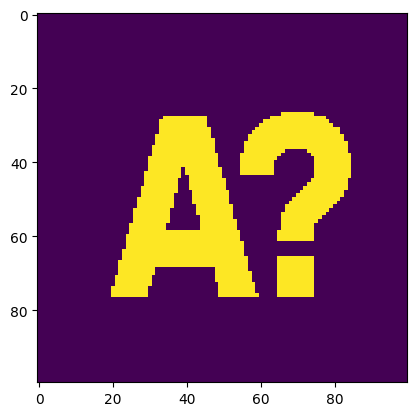

In [64]:
import numpy as np
from PIL import Image
from utils.Helper_Functions import normalize
import matplotlib.pyplot as plt
import torch.nn.functional as F
# choose the recon amp 
im = np.array(Image.open('./data/Aalto-logo.png').convert('L'))
target1 = torch.tensor(im, dtype=torch.float).unsqueeze(0).unsqueeze(0)
target1 = normalize(target1)
print(target1.shape)
target1 = F.pad(input=target1, pad=(60, 60, 60, 60), mode='constant', value=0)
target1 = nn.functional.interpolate(torch.round(target1), size=[100, 100])
plt.imshow(target1[0,0,:,:])

torch.Size([1, 1, 200, 200])


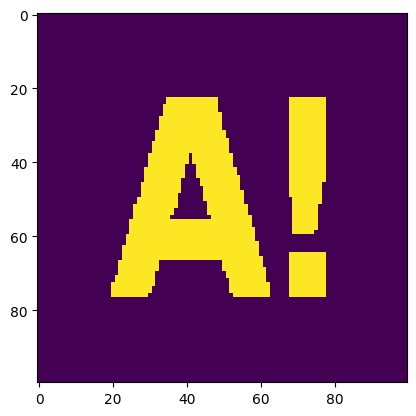

In [67]:
# choose the recon amp 
im = np.array(Image.open('./data/Aalto-logo2.png').convert('L'))
target2 = torch.tensor(im, dtype=torch.float).unsqueeze(0).unsqueeze(0)
target2 = normalize(target2)
print(target2.shape)
target2 = F.pad(input=target2, pad=(35, 35, 35, 35), mode='constant', value=0)
target2 = nn.functional.interpolate(torch.round(target2), size=[100, 100])
plt.imshow(target2[0,0,:,:])

In [68]:
def npcc_loss(X, Y):
    X_mean = torch.mean(X, dim=(2,3), keepdim=True)
    Y_mean = torch.mean(Y,dim=(2,3), keepdim=True) 
    a = torch.sum((X - X_mean)*(Y - Y_mean), dim=(2,3), keepdim=True)
    b = torch.sqrt(torch.sum((X - X_mean)**2, dim=(2,3), keepdim=True)
                   *torch.sum((Y - Y_mean)**2, dim=(2,3), keepdim=True))
    npcc = torch.mean(-a/b)
    return npcc

In [199]:
class Submm_Setupv2(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 optim_params,
                 wavelengths, 
                 device='cuda:0',
                 q_method=None):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        self.optim_params = optim_params
        self.device = device
        self.wavelengths = wavelengths
        
        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        if q_method == None:
            self.doe = FullPrecisionDOELayer(self.doe_params)
            
        elif q_method == 'sgs':
            self.doe = SoftGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'gs':
            self.doe = NaiveGumbelQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'psq':
            self.optim_params = {'c_s': 300,'tau_max': 200,'tau_min': 1}
            self.doe = PSQuantizedDOELayer(self.doe_params, self.optim_params)
            
        elif q_method == 'ste':
            self.doe = STEQuantizedDOELayer(self.doe_params, self.optim_params)
        
        
        self.asm_prop3 = ASM_prop(z_distance=80 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=2, 
                         bandlimit_kernel=True)
        
        self.asm_prop4 = ASM_prop(z_distance=100 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=2, 
                         bandlimit_kernel=True)
        
    
    def forward(self, iter_frac):

        input_field = self.source()
        
        field = self.aperture(self.doe(input_field, iter_frac))
        
        final_field1 = self.asm_prop3(field)

        final_field2 = self.asm_prop4(field)
        
        return [final_field1, final_field2]

In [200]:
setup = Submm_Setupv2(input_dxy=input_dxy, 
                   input_field_shape=input_field_shape, 
                   doe_params=doe_params, 
                   optim_params=optim_params,
                   wavelengths=wavelengths, 
                   q_method='psq')

In [201]:
max_itrs = 12000

losses = []
itr_list = []
itr_to_save_plots = []
setup.cuda()
target1 = target1.cuda()
target2 = target2.cuda()
optimizer = torch.optim.AdamW(setup.parameters(), lr=2e-2)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4000, gamma=0.1)
photometric_loss_fn = nn.MSELoss() #npcc_loss #nn.MSELoss()

best_loss = 10

for itr in range(max_itrs):
    field_list = setup.forward(iter_frac=itr/max_itrs)
    out_field_1 = field_list[0]
    out_field_2 = field_list[1]
    out_amp_1 = normalize(torch.abs(out_field_1.data)**2)
    out_amp_2 = normalize(torch.abs(out_field_2.data)**2)
    loss = photometric_loss_fn(out_amp_1, target1) + photometric_loss_fn(out_amp_2, target2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    #grad = setup.hologram.weight_height_map.grad
    #print(grad)

    losses.append(loss.item())
    itr_list.append(itr)
    #scheduler.step()
    if itr % 200 == 0 or itr == (max_itrs-1):
        print("The iteration : {}, Loss: {}".format(itr, loss))
        #out_field_1.visualize(flag_axis = True, figsize=(6,6), wavelength=wavelengths, intensity=True)
        #out_field_2.visualize(flag_axis = True, figsize=(6,6), wavelength=wavelengths, intensity=True)
    
    if loss < best_loss:
        best_setup = setup
        best_loss = loss
        best_field1 = out_field_1
        best_field2 = out_field_2

The critical distance is [0.25980765] m, the TF will be fine during the sampling !
The critical distance is [0.25980765] m, the TF will be fine during the sampling !
The iteration : 0, Loss: 0.265608549118042
The iteration : 200, Loss: 0.14218448102474213
The iteration : 400, Loss: 0.12157593667507172
The iteration : 600, Loss: 0.11339990794658661
The iteration : 800, Loss: 0.10722294449806213
The iteration : 1000, Loss: 0.10713519155979156
The iteration : 1200, Loss: 0.1051291823387146
The iteration : 1400, Loss: 0.1045299768447876
The iteration : 1600, Loss: 0.1068589985370636
The iteration : 1800, Loss: 0.10563261806964874
The iteration : 2000, Loss: 0.10638126730918884
The iteration : 2200, Loss: 0.10705450177192688
The iteration : 2400, Loss: 0.1087830513715744
The iteration : 2600, Loss: 0.10894468426704407
The iteration : 2800, Loss: 0.10990055650472641
The iteration : 3000, Loss: 0.11178699135780334
The iteration : 3200, Loss: 0.11274538934230804
The iteration : 3400, Loss: 0.1

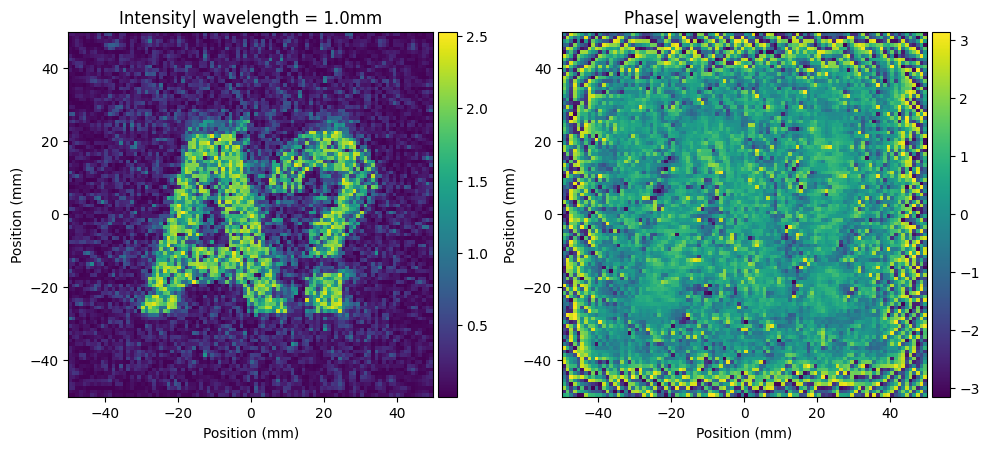

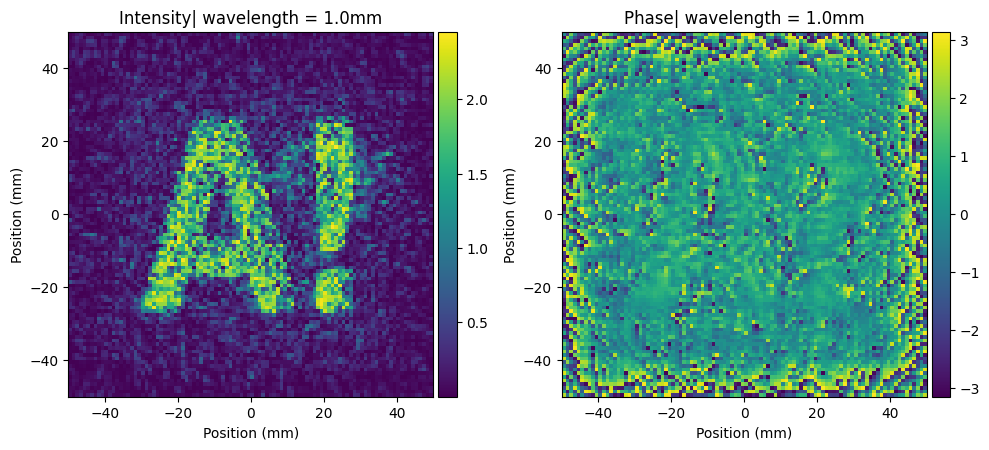

In [202]:
best_field1.visualize(flag_axis = True, figsize=(10,10), wavelength=wavelengths, intensity=True)
best_field2.visualize(flag_axis = True, figsize=(10,10), wavelength=wavelengths, intensity=True)

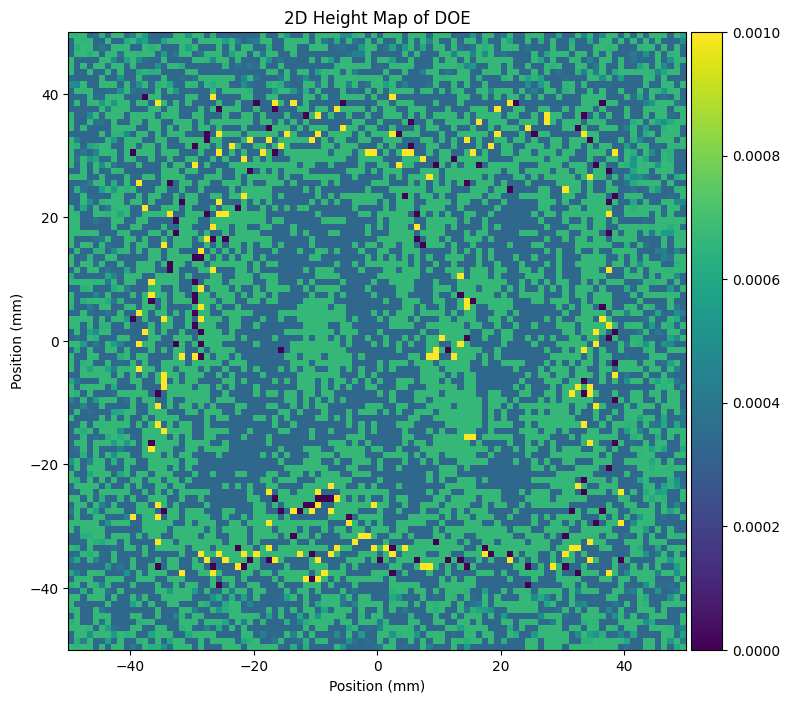

In [203]:
best_setup.doe.visualize(figsize=(8,8))

In [204]:
best_setup.doe.save(crop_size=[80, 80])

tensor(10.3582, device='cuda:0', grad_fn=<DivBackward0>)


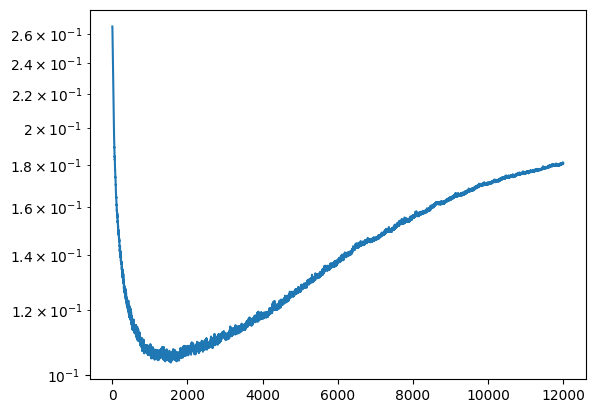

In [205]:
print(best_loss / 1e-2)
np.save('loss_curve_holo_psq.npy', losses)
plt.plot(losses)
plt.yscale('log')